---

#  Concept Explanation

From the previous notebook:

* Embeddings understand **word meaning**
* But NOT:

  * Order 
  * Context 

Example:

```python
"dog bites man"
"man bites dog"
```

Same words → same embeddings → WRONG meaning

---

## Solution: RNN (Recurrent Neural Network)

An **RNN** processes text **sequentially**:

Word by word:

```python
"I" → "love" → "NLP"
```

At each step:

* It remembers previous information using a **hidden state**

---

## Core Idea

```id="v8r3xb"
h_t = f(x_t, h_{t-1})
```

* `x_t` → current word
* `h_{t-1}` → previous memory
* `h_t` → new memory

---

## Problem with RNN

* Cannot remember long sequences
* **Vanishing gradient problem**

It “forgets” earlier words

---

## Solution: LSTM (Long Short-Term Memory)

LSTM improves RNN by adding:

* Memory cell 
* Gates (control what to keep or forget)

---

## LSTM Gates (Conceptual)

* Forget gate → what to remove
* Input gate → what to add
* Output gate → what to use

---

# Why It Matters

Without LSTM:

* No understanding of sequence

With LSTM:

* Understands **order + context**
* Works well for:

  * Sentiment analysis
  * Text classification
  * Language modeling

---

# Simple Example (Intuition)

Sentence:

```python
"I did not like the movie"
```

The word **"not"** changes everything

* Without sequence → model may think it's positive 
* With LSTM → understands negation 

# Import Libraries

In [1]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence

# Example Data

In [2]:
sentences = [
    "i love nlp",
    "i hate bugs",
    "nlp is fun",
    "bugs are annoying"
]

labels = [1, 0, 1, 0]  # 1 = positive, 0 = negativ

# Build Vocabulary

In [3]:
words = set(" ".join(sentences).split())
word2idx = {word: i for i, word in enumerate(words)}

def encode(sentence):
    return [word2idx[word] for word in sentence.split()]

encoded = [torch.tensor(encode(s)) for s in sentences]
padded = pad_sequence(encoded, batch_first=True)

labels = torch.tensor(labels).float().unsqueeze(1)

# Define LSTM Model

In [4]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        out = self.sigmoid(out)
        return out

# Initialize Model

In [5]:
model = LSTMModel(
    vocab_size=len(word2idx),
    embed_dim=8,
    hidden_dim=16
)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training Loop

In [6]:
losses = []

for epoch in range(100):
    outputs = model(padded)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.4283
Epoch 20, Loss: 0.1092
Epoch 30, Loss: 0.0203
Epoch 40, Loss: 0.0068
Epoch 50, Loss: 0.0038
Epoch 60, Loss: 0.0027
Epoch 70, Loss: 0.0021
Epoch 80, Loss: 0.0018
Epoch 90, Loss: 0.0016
Epoch 100, Loss: 0.0014


# Visualization / Results

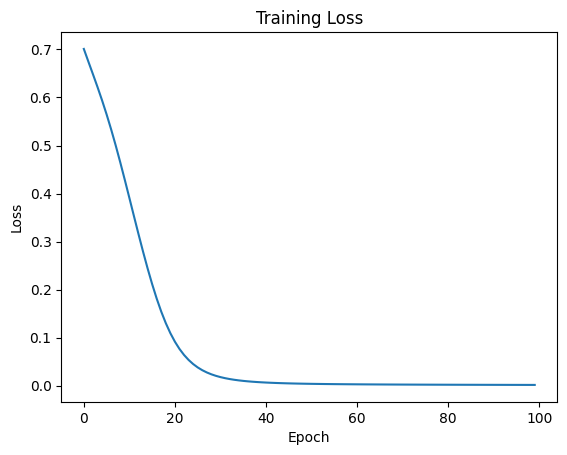

In [7]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Predictions

In [8]:
with torch.no_grad():
    test_sentence = "i love bugs"
    test_encoded = torch.tensor([encode(test_sentence)])
    
    prediction = model(test_encoded)
    print(prediction)

tensor([[0.9560]])


# Limitations

- Slow to train
- Hard to parallelize
- Struggles with very long sequences
- Still not perfect with context

---

# Mini Summary

* RNN processes text sequentially
* LSTM improves memory using gates
* Captures **order + context**
* Much better than embeddings alone

---

# Connection to Previous Notebook

* Before: words → vectors (embeddings)
* Now: vectors → **sequence understanding (LSTM)**

---

# Next Notebook: `04_attention`

We will solve:

> LSTM still struggles with long sentences 

Solution → **Attention mechanism**

---
